In [1]:
import numpy as np
import networkx as nx
from numpy.random import default_rng
from scipy.linalg import solve  # 用 solve 避免显式求逆

rng = default_rng(42)

def neuronal_activity(A_norm, x0, beta, h, max_iter=500, tol=1e-8):
    """
    迭代求稳态: x = tanh(beta * A_norm @ x + h)
    - A_norm: (N,N)
    - x0:     (N,)
    - h:      (N,)
    返回 x (N,)
    """
    x = x0.copy()
    for _ in range(max_iter):
        x_new = np.tanh(beta * (A_norm @ x) + h)
        if np.max(np.abs(x_new - x)) < tol:
            return x_new
        x = x_new
    return x  # 如未收敛，也返回最后一次

def clustering_coefficient(adj_bool):
    """
    平均聚类系数（把图视作无向无权）
    adj_bool: (N,N) 的 {0,1} 矩阵，对称且对角为 0
    """
    G = nx.from_numpy_array(adj_bool.astype(bool))
    return nx.average_clustering(G)

# ---- 参数 ----
N = 1000
E = N * (N - 1) // 2
s_avg = 1
num_syn = int(round(s_avg * E))
p = 0.5
beta = 0.1
num_samples = 100
num_updatesPerSample = 100
num_prunesPerUpdate = int(np.ceil(E / num_updatesPerSample))
num_updatesBurn = 50 * num_updatesPerSample

# ---- 结果容器 ----
s_values_list = [None] * num_samples
s_counts_list = [None] * num_samples
density = np.zeros(num_samples)
heterogeneity = np.zeros(num_samples)
clustering_vals = np.zeros(num_samples)

# ---- 上三角索引（无向边的线性索引）----
I_triu, J_triu = np.triu_indices(N, k=1)  # 长度 E

# ---- 随机初始化：往 E 条可能边里“放入” num_syn 个单位（可重复抽样）----
# A 是对称整数权邻接矩阵
A = np.zeros((N, N), dtype=np.int32)

inds_sample = rng.integers(low=0, high=E, size=num_syn, endpoint=False)  # replace=True
# 批量计数每条边被抽中的次数
counts = np.bincount(inds_sample, minlength=E).astype(np.int32)

# 把计数写回到矩阵（无向 → 对称）
A[I_triu, J_triu] = counts
A[J_triu, I_triu] = counts

def compute_C(A, s_avg, beta):
    # 归一化
    A_norm = A / (s_avg * N)
    # 稳态活动
    x0 = np.zeros(N, dtype=float)
    h = -np.ones(N, dtype=float)
    x = neuronal_activity(A_norm, x0, beta, h)
    # D = diag(1 - x^2)
    d = 1.0 - x**2  # 向量形式的对角
    # 线性系统: (I - beta * D * A_norm)^{-1} * D
    # 先构造 M = I - beta * diag(d) @ A_norm
    M = np.eye(N) - beta * (d[:, None] * A_norm)
    # 右端是 D（对角）→ 等于把每个单位向量 e_i 乘以 d_i，等价于把单位矩阵按列缩放
    # 等价于解 N 个 RHS。为简单起见，直接整块解：
    D_full = np.diag(d)
    X = solve(M, D_full, assume_a='gen')  # N×N
    C = beta * X
    return C, A_norm, x, d

# ---- Burn-in ----
C, A_norm, x, d = compute_C(A, s_avg, beta)

for _ in range(num_updatesBurn):
    # 1) 选要修剪的边（不放回）
    inds_remove = rng.choice(E, size=num_prunesPerUpdate, replace=False)
    # 被删除的权重总和
    w_removed = A[I_triu[inds_remove], J_triu[inds_remove]].sum(dtype=np.int64)

    # 修剪：置零这些边（对称）
    A[I_triu[inds_remove], J_triu[inds_remove]] = 0
    A[J_triu[inds_remove], I_triu[inds_remove]] = 0

    # 2) 把 w_removed 又加回去，其中 Hebbian 的份额：
    if w_removed > 0:
        s_Hebb = rng.binomial(w_removed, p)
        s_rand = w_removed - s_Hebb

        # Hebbian 按 C 的上三角权重分布抽样
        probs = C[I_triu, J_triu].copy()
        probs = np.maximum(probs, np.finfo(float).tiny)
        probs /= probs.sum()

        if s_Hebb > 0:
            inds_inc_Hebb = rng.choice(E, size=s_Hebb, replace=True, p=probs)
        else:
            inds_inc_Hebb = np.empty(0, dtype=int)

        # 随机均匀抽样
        if s_rand > 0:
            inds_inc_rand = rng.integers(low=0, high=E, size=s_rand, endpoint=False)
        else:
            inds_inc_rand = np.empty(0, dtype=int)

        inds_inc = np.concatenate([inds_inc_Hebb, inds_inc_rand])

        # 批量 +1（对称）
        # 用 add.at 在上三角累加，再镜像到下三角更高效
        add_buf = np.zeros(E, dtype=np.int32)
        np.add.at(add_buf, inds_inc, 1)
        A[I_triu, J_triu] += add_buf
        A[J_triu, I_triu] += add_buf

    # 更新 C（代价大；和 MATLAB 一样每步都算）
    C, A_norm, x, d = compute_C(A, s_avg, beta)

# ---- 采样阶段 ----
for si in range(num_samples):
    for _ in range(num_updatesPerSample):
        inds_remove = rng.choice(E, size=num_prunesPerUpdate, replace=False)
        w_removed = A[I_triu[inds_remove], J_triu[inds_remove]].sum(dtype=np.int64)
        A[I_triu[inds_remove], J_triu[inds_remove]] = 0
        A[J_triu[inds_remove], I_triu[inds_remove]] = 0

        if w_removed > 0:
            s_Hebb = rng.binomial(w_removed, p)
            s_rand = w_removed - s_Hebb

            probs = C[I_triu, J_triu].copy()
            probs = np.maximum(probs, np.finfo(float).tiny)
            probs /= probs.sum()

            inds_inc_Hebb = rng.choice(E, size=s_Hebb, replace=True, p=probs) if s_Hebb > 0 else np.empty(0, int)
            inds_inc_rand = rng.integers(low=0, high=E, size=s_rand, endpoint=False) if s_rand > 0 else np.empty(0, int)

            inds_inc = np.concatenate([inds_inc_Hebb, inds_inc_rand])
            add_buf = np.zeros(E, dtype=np.int32)
            np.add.at(add_buf, inds_inc, 1)
            A[I_triu, J_triu] += add_buf
            A[J_triu, I_triu] += add_buf

        # 相关矩阵更新
        C, A_norm, x, d = compute_C(A, s_avg, beta)

    # ----- 记录统计量 -----
    # 边权（上三角）
    conn_strengths = A[I_triu, J_triu]
    conn_strengths = conn_strengths[conn_strengths > 0]

    # 唯一权值及各自计数（等价于 histcounts(..., [s_values, inf])）
    if conn_strengths.size == 0:
        s_vals = np.array([], dtype=int)
        s_cnts = np.array([], dtype=int)
    else:
        s_vals, s_cnts = np.unique(conn_strengths, return_counts=True)

    s_values_list[si] = s_vals
    s_counts_list[si] = s_cnts

    # density
    density[si] = conn_strengths.size / E

    # clustering（基于二值图）
    adj_bool = (A > 0).astype(np.uint8)
    np.fill_diagonal(adj_bool, 0)
    clustering_vals[si] = clustering_coefficient(adj_bool)

    # heterogeneity（与 MATLAB 等式一致）
    if s_vals.size > 0:
        p_dist = s_cnts / s_cnts.sum()
        # 下面做 1/2 * sum_{a,b} |(s_a - s_b)| * p_a * p_b / mean(s)
        # 用广播计算
        diff = np.abs(s_vals[:, None] - s_vals[None, :]).astype(float)
        weight = (p_dist[:, None] * p_dist[None, :])
        heterogeneity[si] = 0.5 * np.sum(diff * weight) / conn_strengths.mean()
    else:
        heterogeneity[si] = 0.0

# 输出（示例）
print("density (first 5):", density[:5])
print("clustering (first 5):", clustering_vals[:5])
print("heterogeneity (first 5):", heterogeneity[:5])


density (first 5): [0.34550551 0.34407007 0.34517117 0.34394995 0.34456056]
clustering (first 5): [0.34557009 0.34410887 0.34538832 0.34383214 0.34453065]
heterogeneity (first 5): [0.50551385 0.50893893 0.5093407  0.51097381 0.50909055]


C (upper triangle) stats:
  n = 499500
  mean = 1.425832385668511e-06
  std  = 5.596120438717542e-06
  min  = 1.711898589564125e-08
  1%/5%/50%/95%/99% = [3.026423791062734e-08, 3.509710670786625e-08, 5.848333354614562e-08, 5.685301674563866e-06, 1.6475077720423085e-05]
  fraction > 0: 1.0
  fraction < 0: 0.0


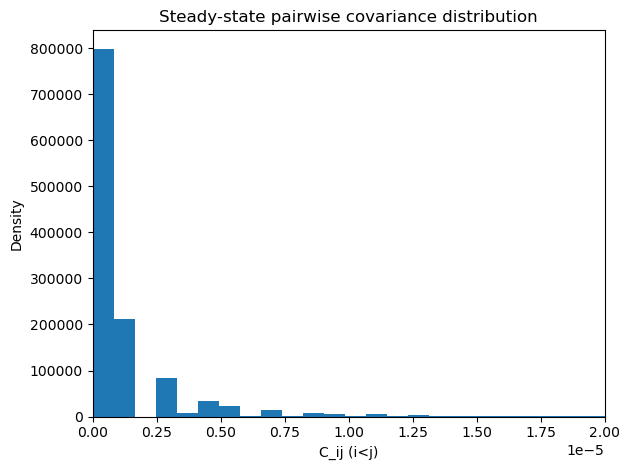

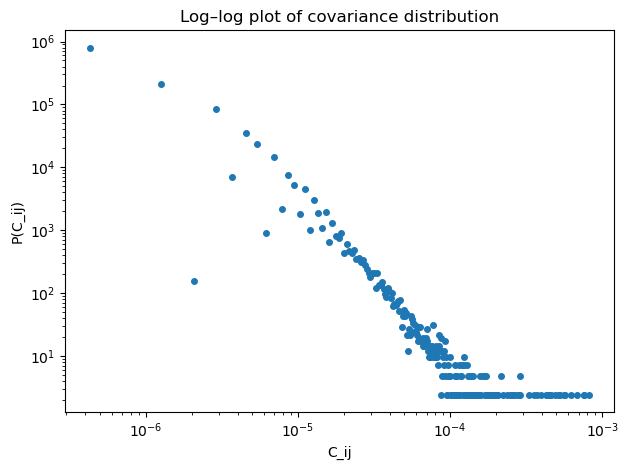

C diagonal mean/std: 0.037131530661065344 0.0005867528934414367


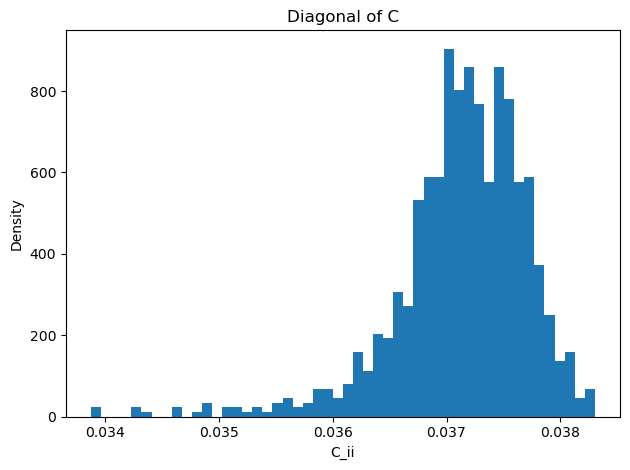

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# —— 取稳态 C 的上三角（去掉对角），当作 pairwise covariance 样本 ——
Cu = C[np.triu_indices(N, k=1)]

# 基本统计
print("C (upper triangle) stats:")
print("  n =", Cu.size)
print("  mean =", float(np.mean(Cu)))
print("  std  =", float(np.std(Cu)))
print("  min  =", float(np.min(Cu)))
print("  1%/5%/50%/95%/99% =", np.percentile(Cu, [1, 5, 50, 95, 99]).tolist())
print("  fraction > 0:", float(np.mean(Cu > 0)))
print("  fraction < 0:", float(np.mean(Cu < 0)))

# 直方图（密度归一化）
plt.figure()
counts, bins, _ = plt.hist(Cu, bins=1000, density=True)
plt.xlabel("C_ij (i<j)")
plt.ylabel("Density")
plt.title("Steady-state pairwise covariance distribution")
plt.xlim(0, 0.00002)
plt.tight_layout()
plt.show()

# power law
mask = (counts > 0)
x = 0.5 * (bins[1:] + bins[:-1])[mask]
y = counts[mask]

plt.figure()
plt.loglog(x, y, 'o', markersize=4)
plt.xlabel("C_ij")
plt.ylabel("P(C_ij)")
plt.title("Log-log plot of covariance distribution")
plt.tight_layout()
plt.show()

# 如需看对角（“方差”/自响应）分布：
Cdiag = np.diag(C)
print("C diagonal mean/std:", float(np.mean(Cdiag)), float(np.std(Cdiag)))
plt.figure()
plt.hist(Cdiag, bins=50, density=True)
plt.xlabel("C_ii")
plt.ylabel("Density")
plt.title("Diagonal of C")
plt.tight_layout()
plt.show()


In [16]:
print(C_sym.shape)

(1000, 1000)


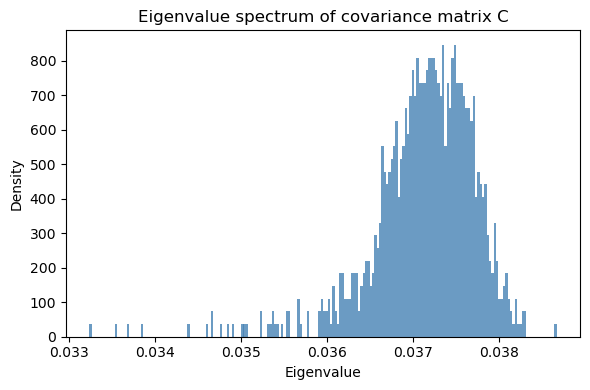

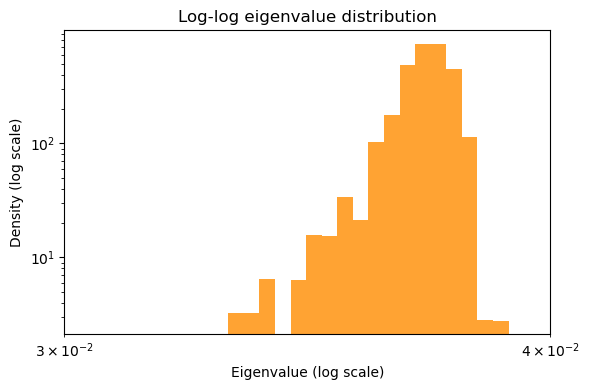

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# 保证 C 对称（数值上可能略有误差）
C_sym = 0.5 * (C + C.T)

# 用 np.linalg.eigvalsh（专为 Hermitian / 对称矩阵优化）
eigvals = np.linalg.eigvalsh(C_sym)

# --------------------------
# 1. 普通线性坐标下的特征值分布
# --------------------------
plt.figure(figsize=(6,4))
plt.hist(eigvals, bins=200, density=True, color='steelblue', alpha=0.8)
plt.xlabel("Eigenvalue")
plt.ylabel("Density")
plt.title("Eigenvalue spectrum of covariance matrix C")
plt.tight_layout()
plt.show()

# --------------------------
# 2. log-log 坐标下的分布
# --------------------------
# 过滤掉极小或负的特征值（由于浮点误差，协方差矩阵理论上应非负）
eigvals_pos = eigvals[eigvals > 1e-12]

plt.figure(figsize=(6,4))
plt.hist(eigvals_pos, bins=np.logspace(-8, 0, 2000), density=True, color='darkorange', alpha=0.8)
plt.xscale('log')
plt.yscale('log')
plt.xlabel("Eigenvalue (log scale)")
plt.ylabel("Density (log scale)")
plt.xlim(3*1e-2, 4*1e-2)   # 建议略放宽范围以免空图（可视情况调）
plt.title("Log-log eigenvalue distribution")
plt.tight_layout()
plt.show()

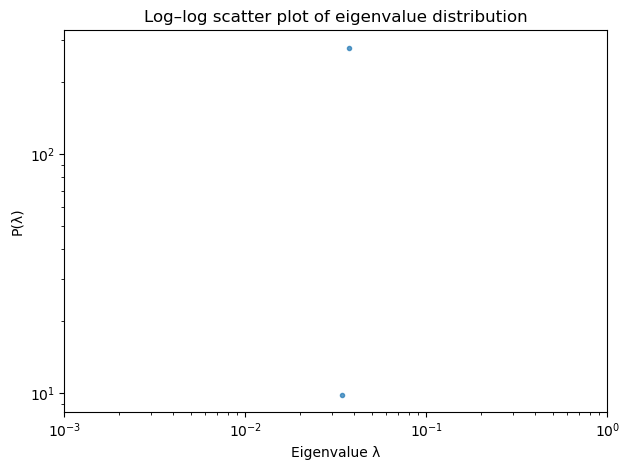

In [12]:
counts, bins = np.histogram(eigvals[eigvals > 1e-12], bins=np.logspace(-8, 0, 200), density=True)
mask = counts > 0
x = 0.5 * (bins[1:] + bins[:-1])[mask]  # bin 中心
y = counts[mask]

plt.figure()
plt.loglog(x, y, 'o', markersize=3, alpha=0.7)
plt.xlabel("Eigenvalue λ")
plt.ylabel("P(λ)")
plt.title("Log–log scatter plot of eigenvalue distribution")
plt.xlim(1e-3, 1e0)  # 你也可以改成 (0.01, 0.1)
plt.tight_layout()
plt.show()


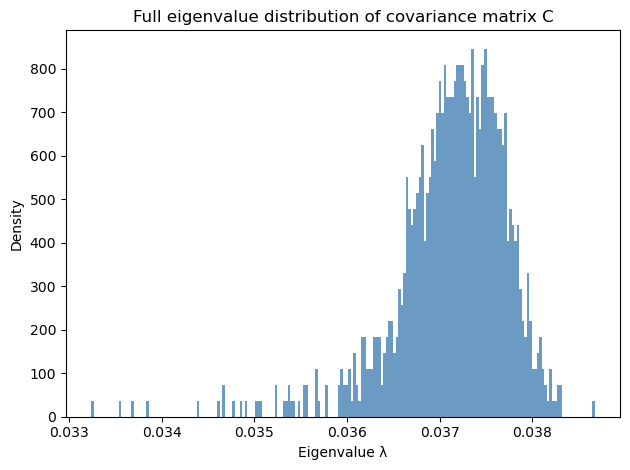

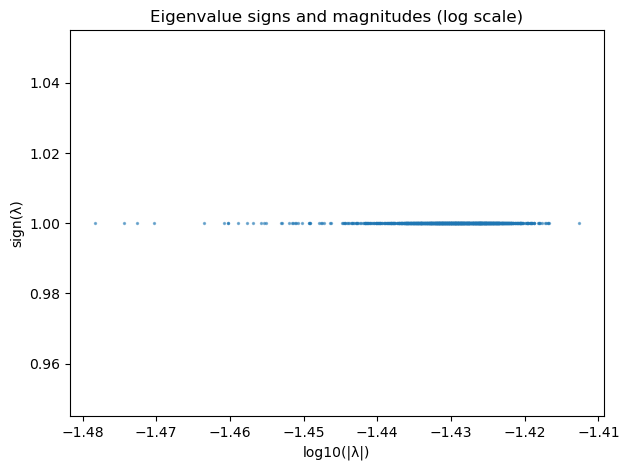

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# 保证对称
C_sym = 0.5 * (C + C.T)

# 计算所有特征值
eigvals = np.linalg.eigvalsh(C_sym)

# —— 普通线性坐标下的分布 ——
plt.figure()
plt.hist(eigvals, bins=200, density=True, color='steelblue', alpha=0.8)
plt.xlabel("Eigenvalue λ")
plt.ylabel("Density")
plt.title("Full eigenvalue distribution of covariance matrix C")
plt.tight_layout()
plt.show()

# —— log–log 散点版本（显示所有值，包括小值和负值）——
# 注意：log 不能处理负数，因此我们改用 sign + log(abs(x)) 形式可视化
sign = np.sign(eigvals)
mag = np.abs(eigvals)
order = np.argsort(mag)
mag_sorted = mag[order]
sign_sorted = sign[order]

plt.figure()
plt.scatter(np.log10(mag_sorted + 1e-16), sign_sorted, s=2, alpha=0.5)
plt.xlabel("log10(|λ|)")
plt.ylabel("sign(λ)")
plt.title("Eigenvalue signs and magnitudes (log scale)")
plt.tight_layout()
plt.show()


In [14]:
print(C)

[[3.69994626e-02 5.57955254e-08 4.48854758e-08 ... 1.40956779e-06
  1.44408441e-06 4.14595361e-06]
 [5.57955254e-08 3.75485004e-02 4.18426633e-08 ... 1.47996685e-06
  4.47176509e-08 5.07315004e-08]
 [4.48854758e-08 4.18426633e-08 3.74199523e-02 ... 1.25194910e-05
  6.46587117e-08 4.20589872e-08]
 ...
 [1.40956779e-06 1.47996685e-06 1.25194910e-05 ... 3.69748196e-02
  1.41578666e-06 5.78785517e-08]
 [1.44408441e-06 4.47176509e-08 6.46587117e-08 ... 1.41578666e-06
  3.71786702e-02 6.62459290e-08]
 [4.14595361e-06 5.07315004e-08 4.20589872e-08 ... 5.78785517e-08
  6.62459290e-08 3.69990909e-02]]
